In [15]:
### PLEASE NOTICE THAT THIS ANALYSIS IS UNRELATED WITH ...

In [52]:
import os
import csv
import tqdm
import numpy as np
import scipy.stats as ss
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 300

In [3]:
def extract_score_from_sdf(filepath: str) -> tuple[str, str | None]:
    """
    Extracts the ENERGY value from the <Uni-Dock RESULT> block in an SDF file.
    """
    try:
        with open(filepath, 'r') as file:
            for line in file:
                if line.strip() == "> <Uni-Dock RESULT>":
                    result_line = next(file).strip()
                    if "ENERGY=" in result_line:
                        return os.path.basename(filepath), result_line.split("ENERGY=")[1].split()[0]
    except Exception:
        pass
    return os.path.basename(filepath), None

def generate_report(directory: str, output_csv: str = "scores.csv", score_field: str = "score"):
    """
    Processes all .sdf files in a directory, extracts score values in parallel,
    and writes the results as a CSV: filename,score.
    """

    # Enumerate SDF files
    sdf_files = [os.path.join(directory, f) for f in sorted(os.listdir(directory)) if f.endswith(".sdf")]

    # Get results
    results = [extract_score_from_sdf(file) for file in tqdm.tqdm(sdf_files)]

    # Write results
    with open(output_csv, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["compound", "score"])
        for compound, score in results:
            writer.writerow([compound.replace("_out.sdf", ""), score if score is not None else ""])

In [ ]:
# this cell needs to be run inthe machine where all files are located - otherwise it's too slow

PATH = "/home/acomajuncosa/Documents_GPU/docking-unidock_benchmarking"
MODES = ['fast', 'balance', 'detail']

for mode in MODES:

    generate_report(os.path.join(PATH, f"output_{mode}"), os.path.join(PATH, f"report_{mode}.csv"))

100%|██████████| 100151/100151 [00:17<00:00, 5605.84it/s]


In [18]:
PATH = "/home/acomajuncosa/Documents_GPU/docking-unidock_benchmarking"
MODES = ['fast', 'balance', 'detail']
DOCKING_RESULTS = {}

# For each mode
for mode in MODES:

        # Get scores
        scores = pd.read_csv(os.path.join(PATH, f'report_{mode}.csv'))

        # Save results
        DOCKING_RESULTS[mode] = {i: j for i, j in zip(scores['compound'], scores['score'])}


In [21]:
# Get sorted compounds ~100k
cpds = sorted(DOCKING_RESULTS['fast'])

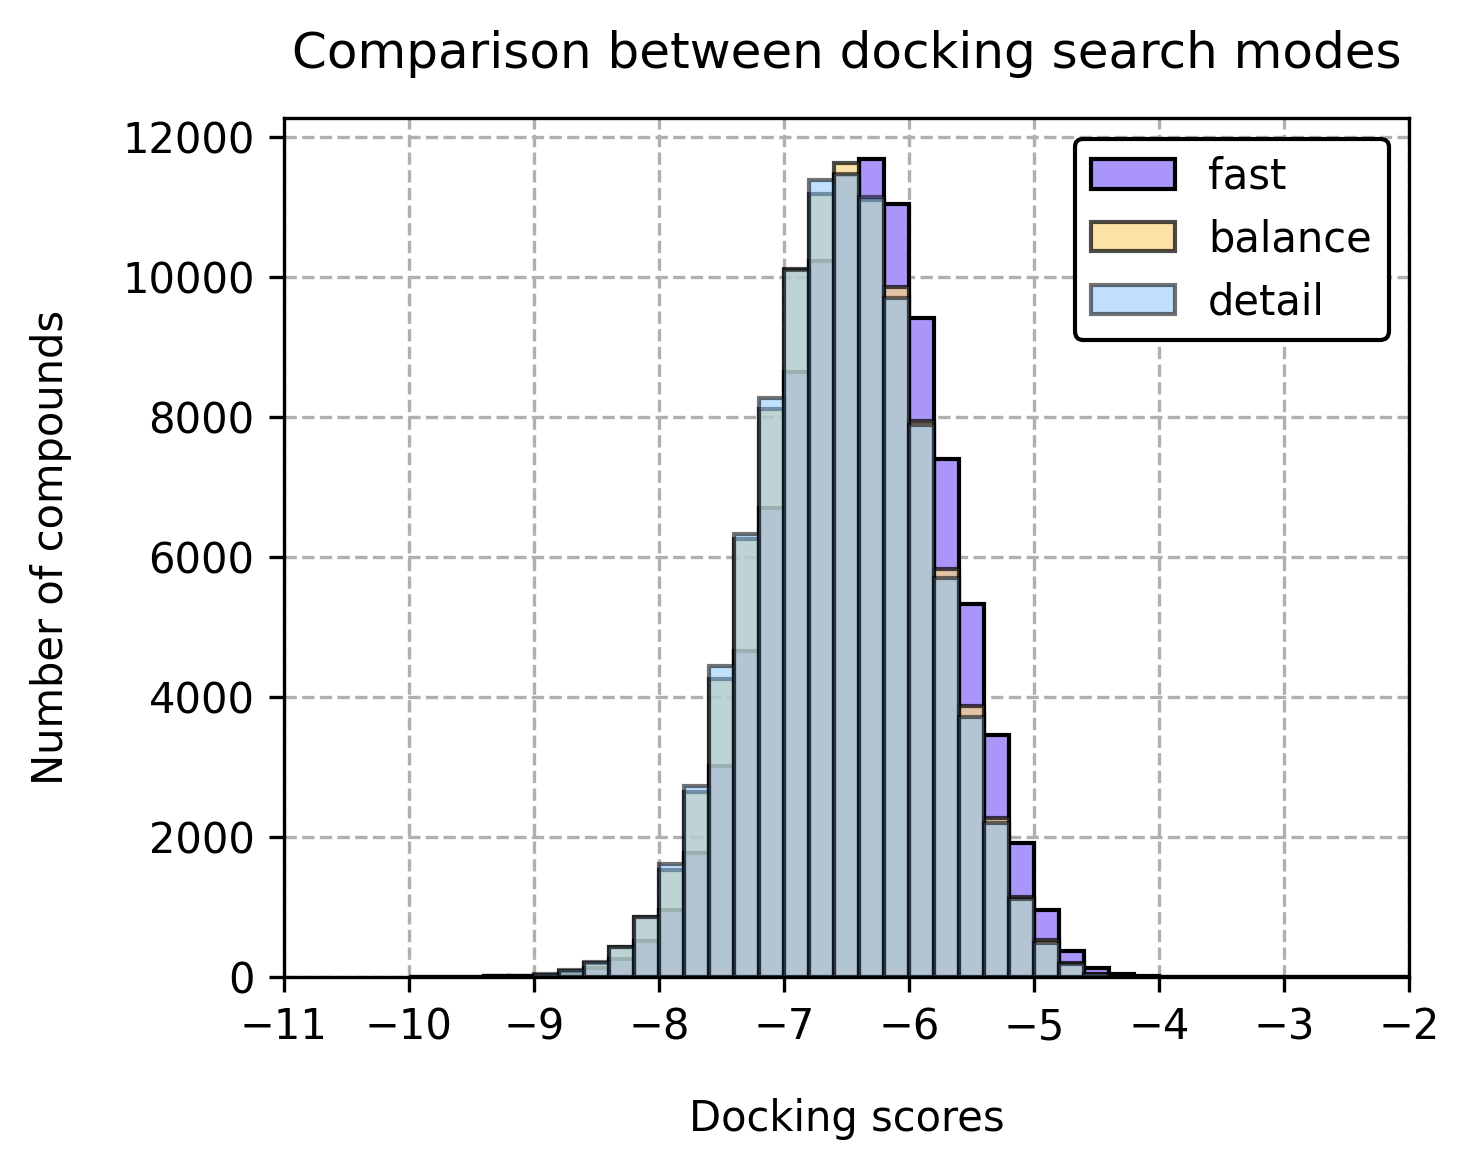

In [42]:
bins = [i for i in np.arange(-10, 1, 0.2)]

plt.figure(figsize=(5, 4))
plt.hist(list(DOCKING_RESULTS["fast"].values()), bins=bins, zorder=2, edgecolor='k', color="#AA96FA", label='fast')
plt.hist(list(DOCKING_RESULTS["balance"].values()), bins=bins, zorder=2, edgecolor='k', color="#FAD782", label='balance', alpha=0.7)
plt.hist(list(DOCKING_RESULTS["detail"].values()), bins=bins, zorder=2, edgecolor='k', color="#8DC7FA", label='detail', alpha=0.55)
plt.grid(linestyle='--', zorder=-2)
plt.xlim([-11, -2])
plt.xlabel("Docking scores", labelpad=12)
plt.ylabel("Number of compounds", labelpad=12)
plt.title("Comparison between docking search modes", pad=12)
plt.legend(framealpha=1, edgecolor='k')
plt.tight_layout()
plt.show()

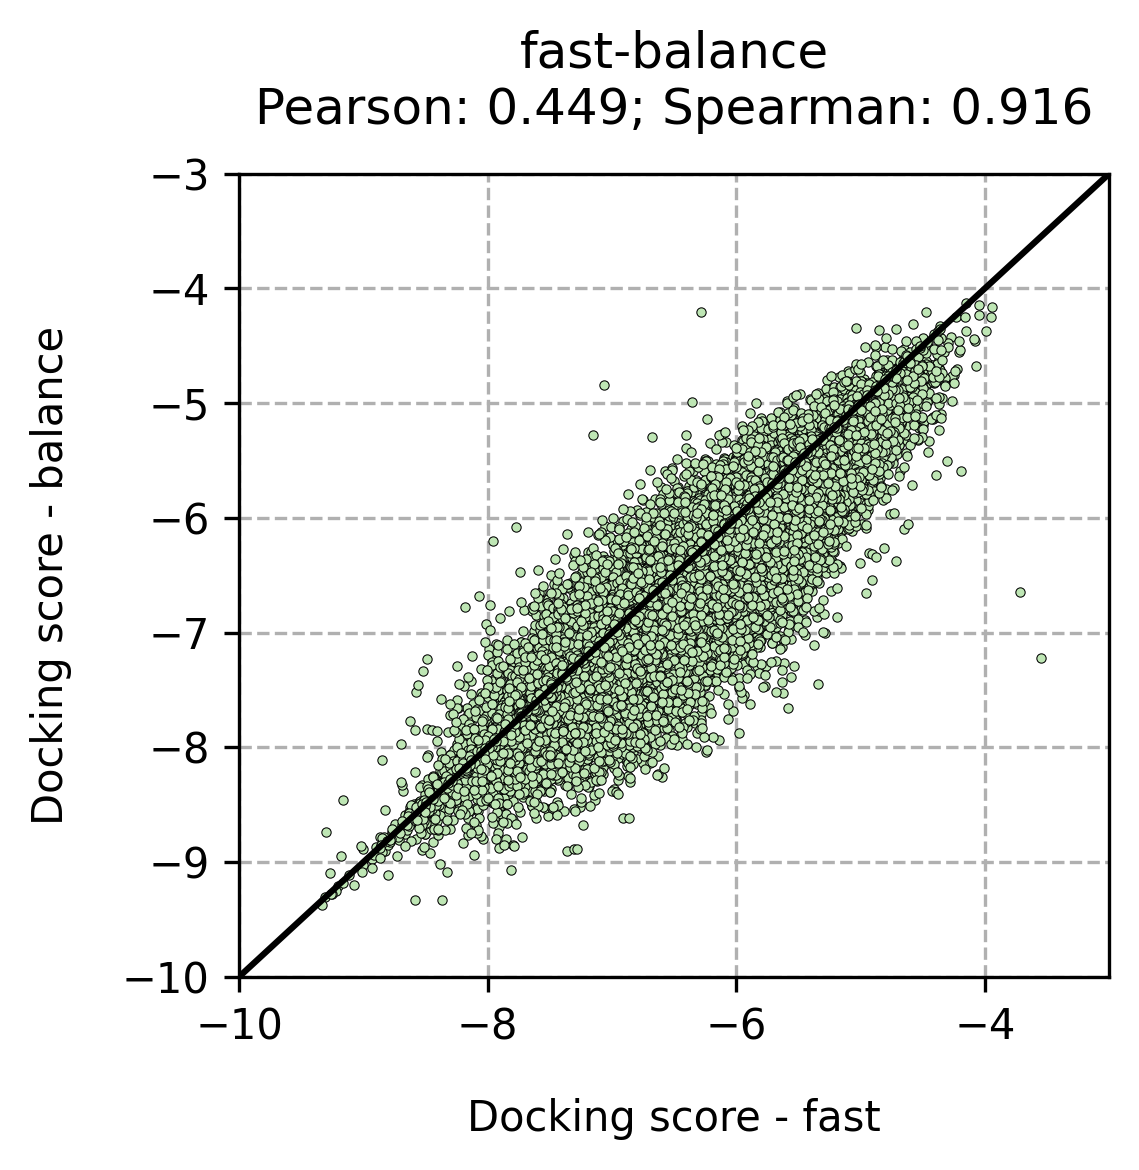

In [74]:
plt.figure(figsize=(4,4))
l1, l2 = 'fast', 'balance'
x = [DOCKING_RESULTS[l1][i] for i in cpds]
y = [DOCKING_RESULTS[l2][i] for i in cpds]

plt.grid(linestyle='--', zorder=-2)
plt.plot([-100, 100], [-100, 100],  c='k', zorder=3)
plt.xlim([-10, -3])
plt.ylim([-10, -3])
plt.scatter(x,y, s=5, zorder=2, ec='k', lw=0.25, c='#BEE6B4')
plt.xlabel(f"Docking score - {l1}", labelpad=12)
plt.ylabel(f"Docking score - {l2}", labelpad=12)
title = f"{l1}-{l2}\nPearson: {round(ss.pearsonr(x,y).statistic, 3)}; Spearman: {round(ss.spearmanr(x,y).statistic, 3)}"
plt.title(title, pad=12)
plt.tight_layout()
plt.show()

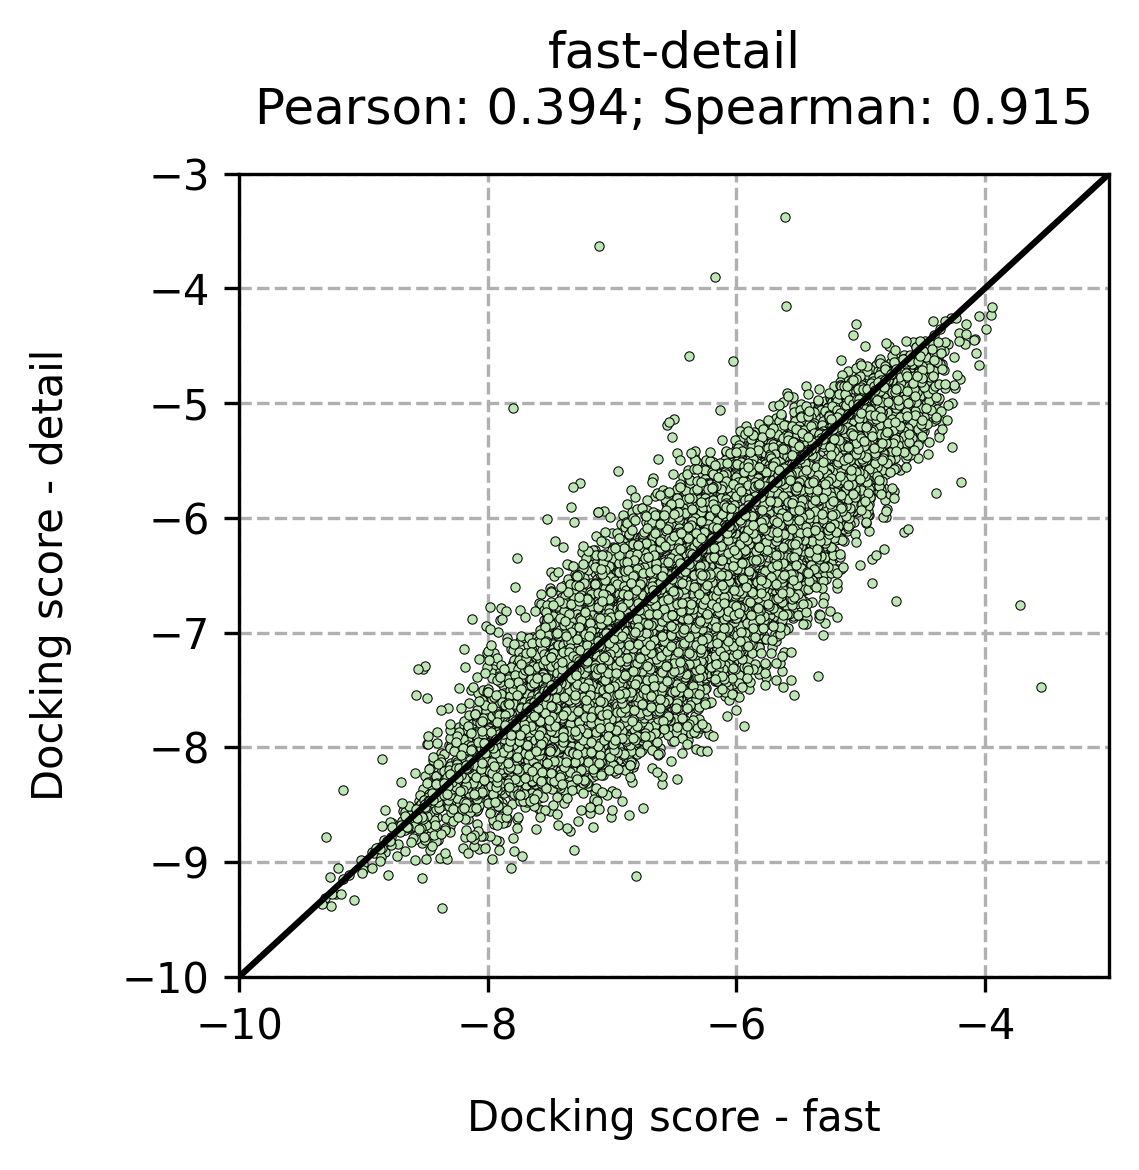

In [ ]:
plt.figure(figsize=(4,4))
l1, l2 = 'fast', 'detail'
x = [DOCKING_RESULTS[l1][i] for i in cpds]
y = [DOCKING_RESULTS[l2][i] for i in cpds]

plt.grid(linestyle='--', zorder=-2)
plt.plot([-100, 100], [-100,b 100],  c='k', zorder=3)
plt.xlim([-10, -3])
plt.ylim([-10, -3])
plt.scatter(x,y, s=5, zorder=2, ec='k', lw=0.25, c='#BEE6B4')
plt.xlabel(f"Docking score - {l1}", labelpad=12)
plt.ylabel(f"Docking score - {l2}", labelpad=12)
title = f"{l1}-{l2}\nPearson: {round(ss.pearsonr(x,y).statistic, 3)}; Spearman: {round(ss.spearmanr(x,y).statistic, 3)}"
plt.title(title, pad=12)
plt.tight_layout()
plt.show()

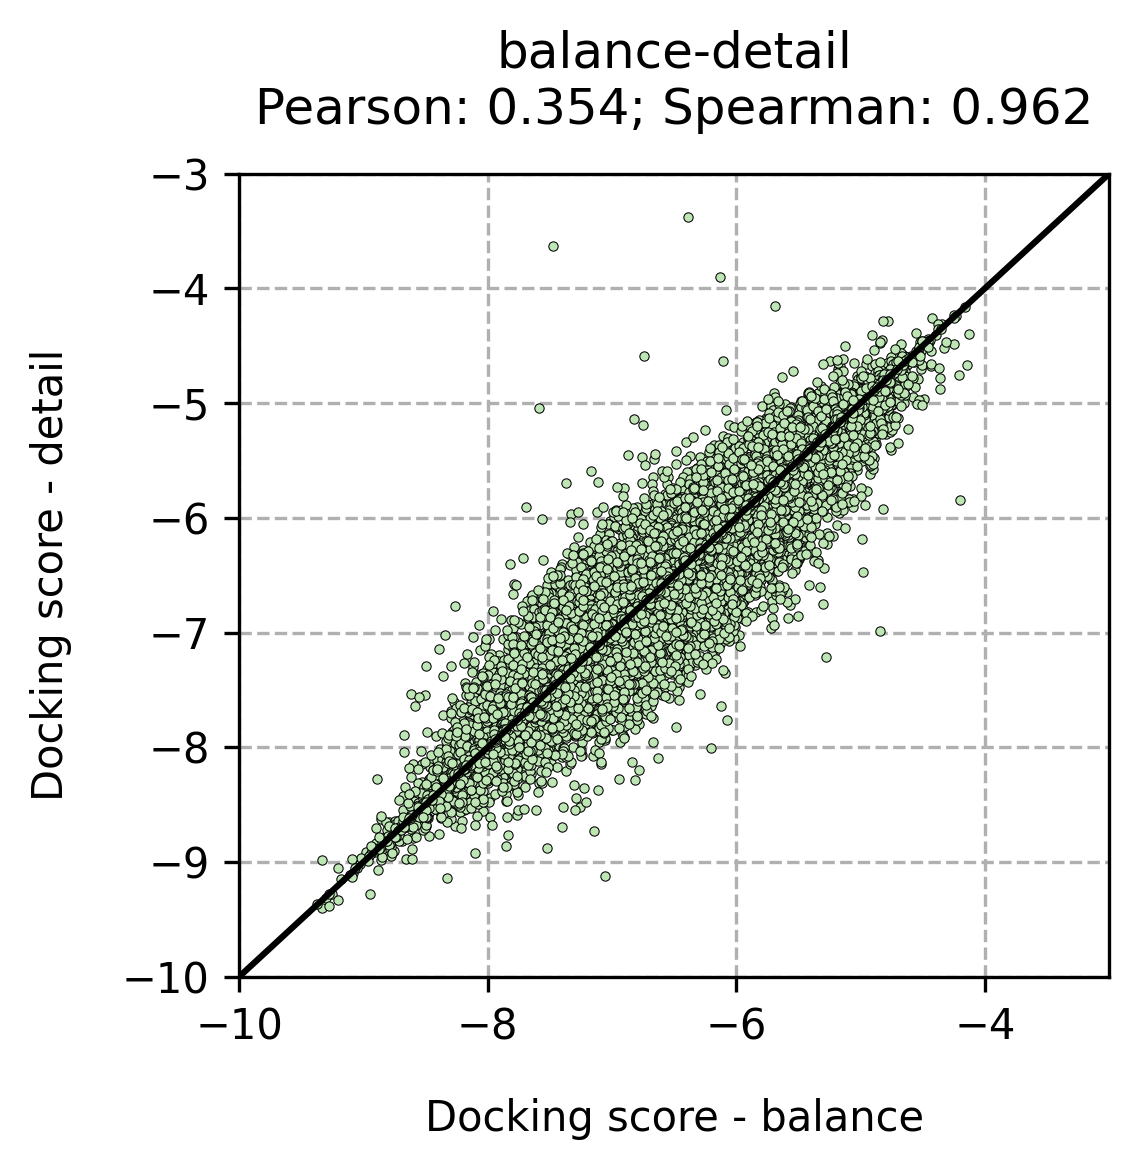

In [78]:
plt.figure(figsize=(4,4))
l1, l2 = 'balance', 'detail'
x = [DOCKING_RESULTS[l1][i] for i in cpds]
y = [DOCKING_RESULTS[l2][i] for i in cpds]

plt.grid(linestyle='--', zorder=-2)
plt.plot([-100, 100], [-100, 100],  c='k', zorder=3)
plt.xlim([-10, -3])
plt.ylim([-10, -3])
plt.scatter(x,y, s=5, zorder=2, ec='k', lw=0.25, c='#BEE6B4')
plt.xlabel(f"Docking score - {l1}", labelpad=12)
plt.ylabel(f"Docking score - {l2}", labelpad=12)
title = f"{l1}-{l2}\nPearson: {round(ss.pearsonr(x,y).statistic, 3)}; Spearman: {round(ss.spearmanr(x,y).statistic, 3)}"
plt.title(title, pad=12)
plt.tight_layout()
plt.show()